In [ ]:
import kagglehub
import os

dataset_path = kagglehub.dataset_download(
    "fedesoriano/company-bankruptcy-prediction"
)

dataset_path

Using Colab cache for faster access to the 'company-bankruptcy-prediction' dataset.


'/kaggle/input/company-bankruptcy-prediction'

In [ ]:
os.listdir(dataset_path)


['data.csv']

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "fedesoriano/company-bankruptcy-prediction",
    'data.csv'
)
print("data:",df.head())

df = df.copy()

df["Id"] = range(len(df))

target = "Bankrupt?"


train_df = df.iloc[:6000].copy()


test_df = df.iloc[6000:].copy()


y_test_true = test_df[target]

test_df = test_df.drop(columns=[target])


X_train = train_df.drop(columns=[target])
y_train = train_df[target]


train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print(train_df.shape)
print(test_df.shape)



Using Colab cache for faster access to the 'company-bankruptcy-prediction' dataset.
data:    Bankrupt?   ROA(C) before interest and depreciation before interest  \
0          1                                           0.370594          
1          1                                           0.464291          
2          1                                           0.426071          
3          1                                           0.399844          
4          1                                           0.465022          

    ROA(A) before interest and % after tax  \
0                                 0.424389   
1                                 0.538214   
2                                 0.499019   
3                                 0.451265   
4                                 0.538432   

    ROA(B) before interest and depreciation after tax  \
0                                           0.405750    
1                                           0.516730    
2                

# **Preprocessing**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 97 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Id
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578,3409.000000
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014,1968.620075
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477,1704.500000
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798,3409.000000
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838,5113.500000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,6818.000000


Bankrupt?


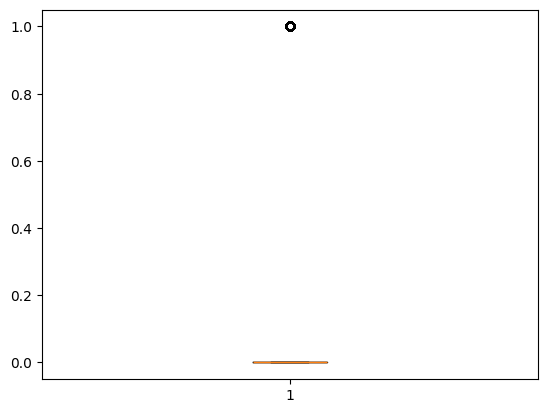

 ROA(C) before interest and depreciation before interest


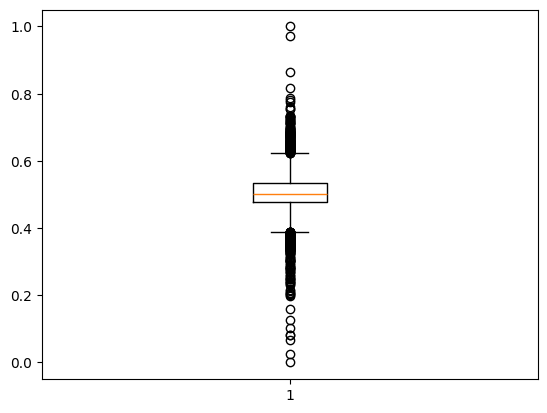

 ROA(A) before interest and % after tax


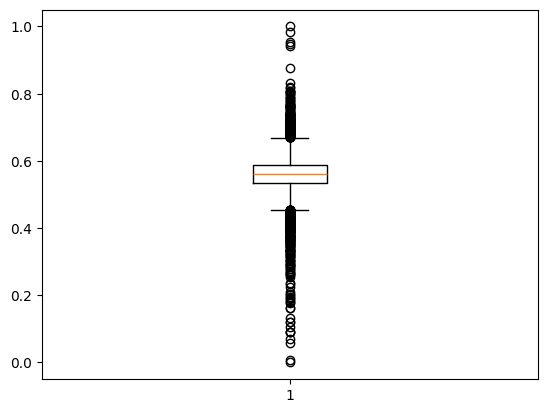

 ROA(B) before interest and depreciation after tax


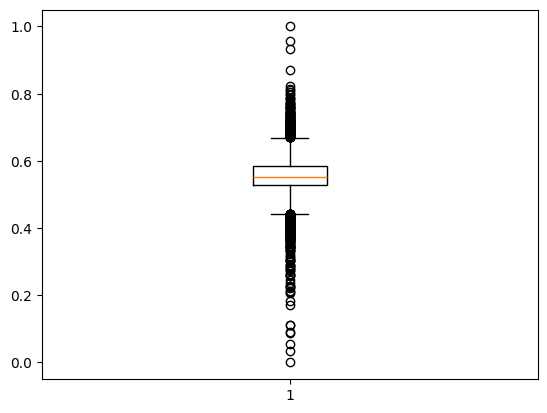

 Operating Gross Margin


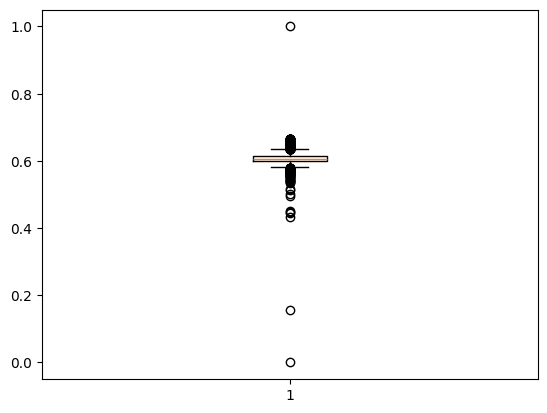

 Realized Sales Gross Margin


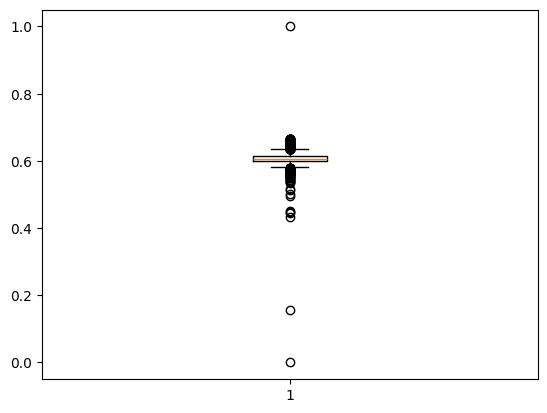

 Operating Profit Rate


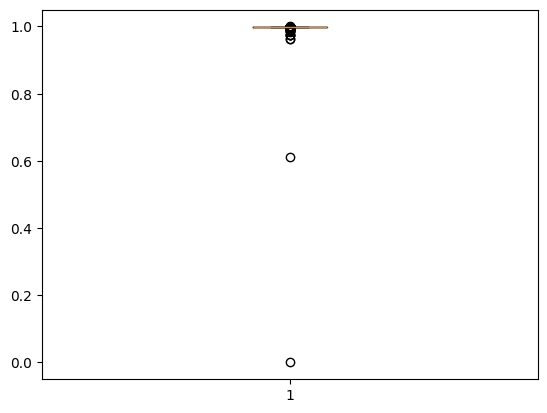

 Pre-tax net Interest Rate


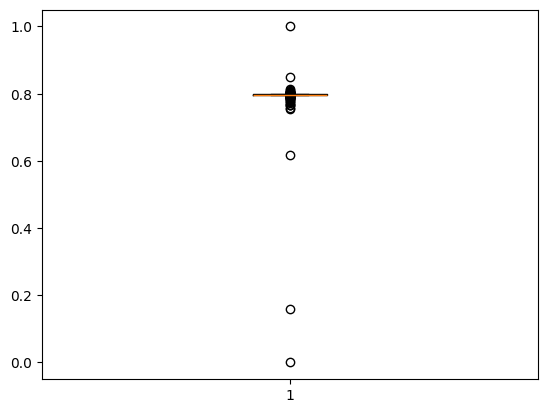

 After-tax net Interest Rate


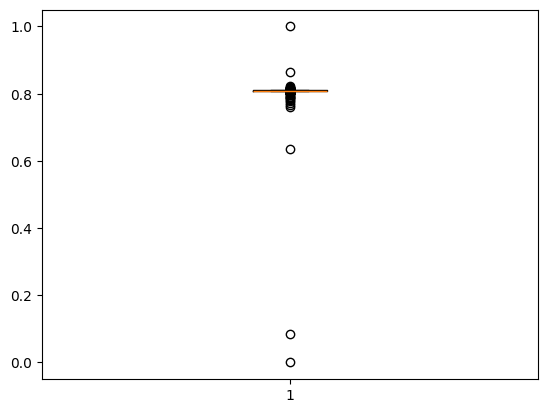

 Non-industry income and expenditure/revenue


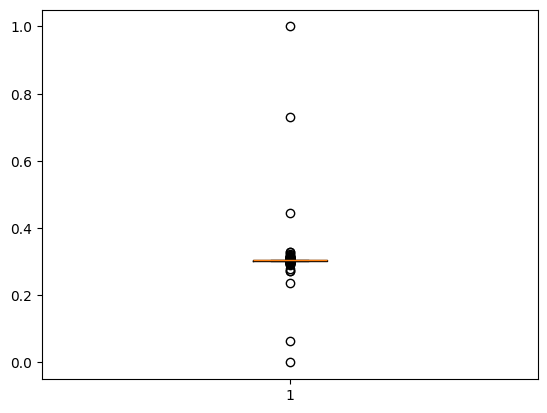

 Continuous interest rate (after tax)


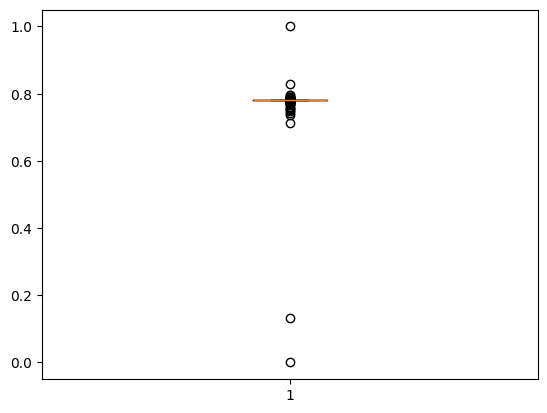

 Operating Expense Rate


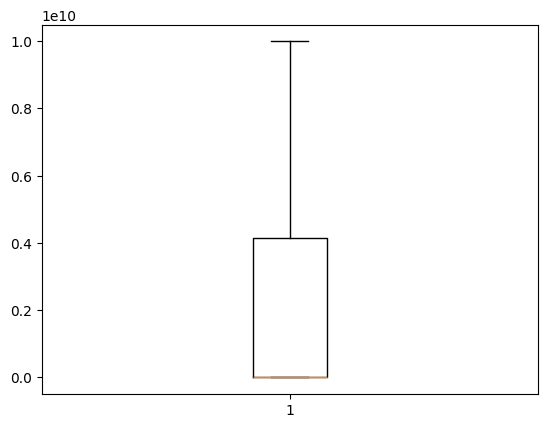

 Research and development expense rate


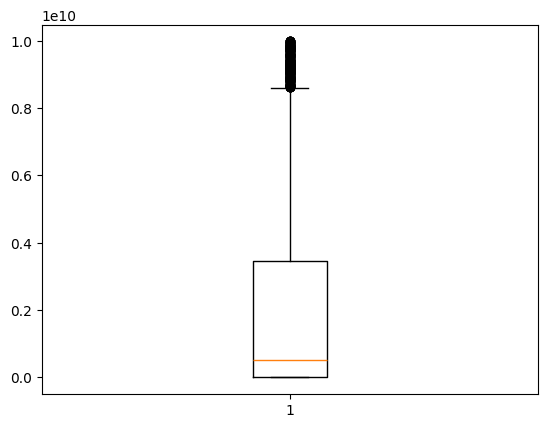

 Cash flow rate


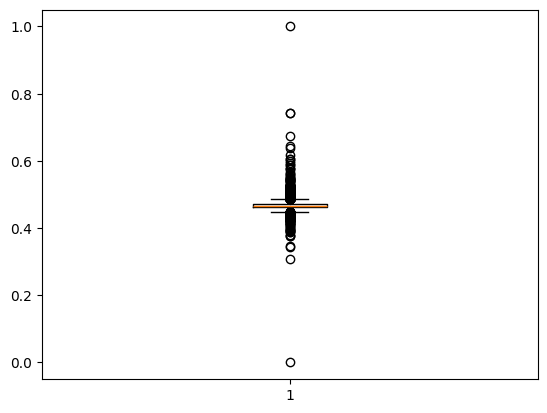

 Interest-bearing debt interest rate


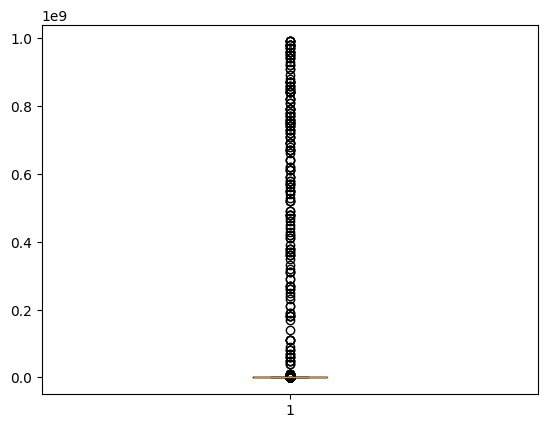

 Tax rate (A)


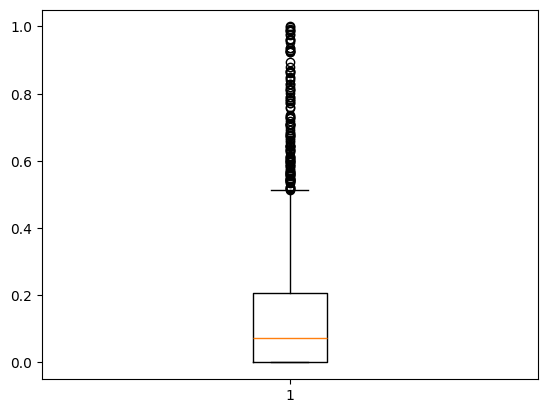

 Net Value Per Share (B)


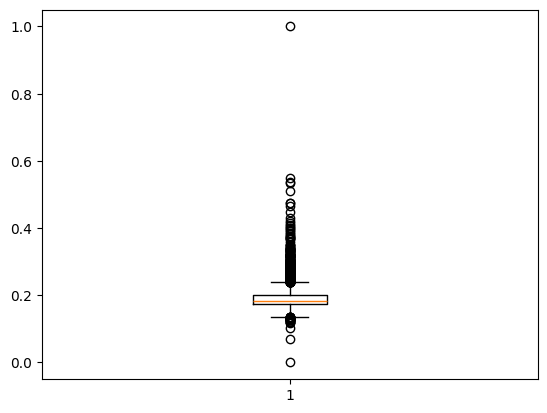

 Net Value Per Share (A)


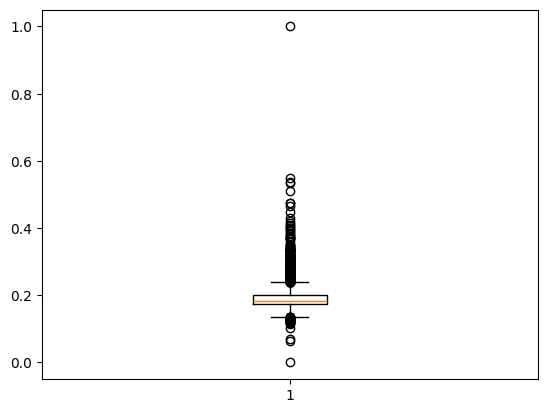

 Net Value Per Share (C)


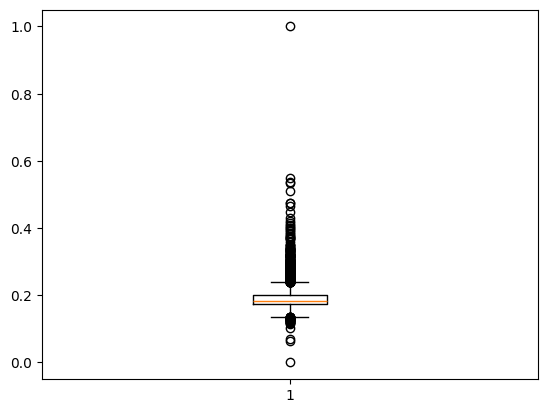

 Persistent EPS in the Last Four Seasons


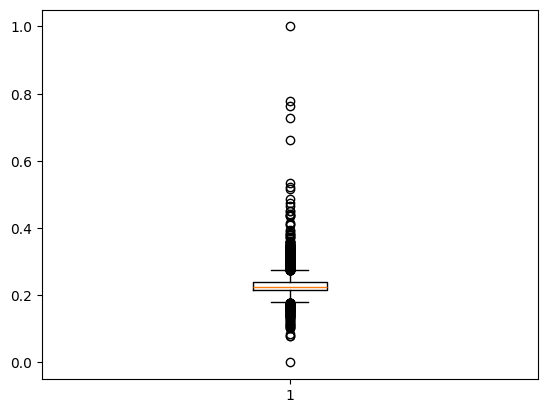

 Cash Flow Per Share


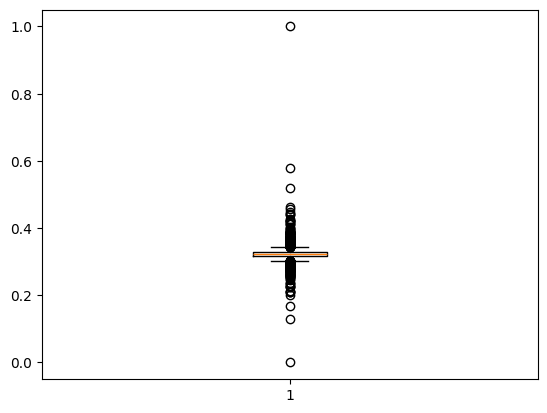

 Revenue Per Share (Yuan ¥)


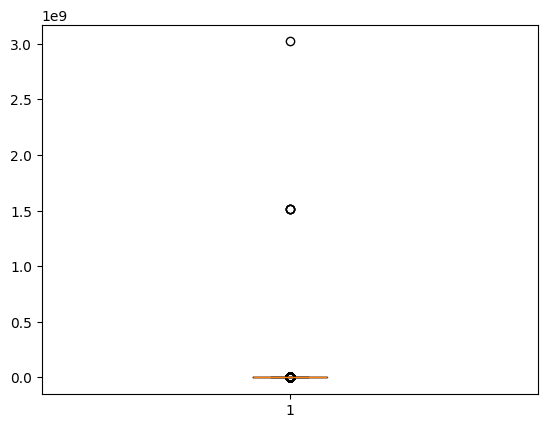

 Operating Profit Per Share (Yuan ¥)


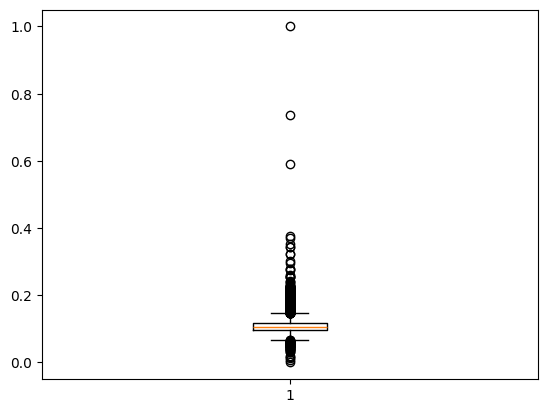

 Per Share Net profit before tax (Yuan ¥)


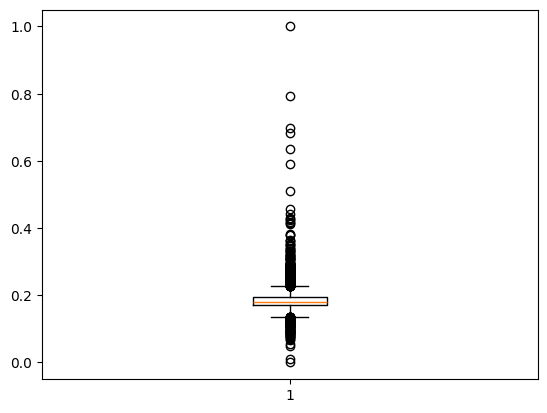

 Realized Sales Gross Profit Growth Rate


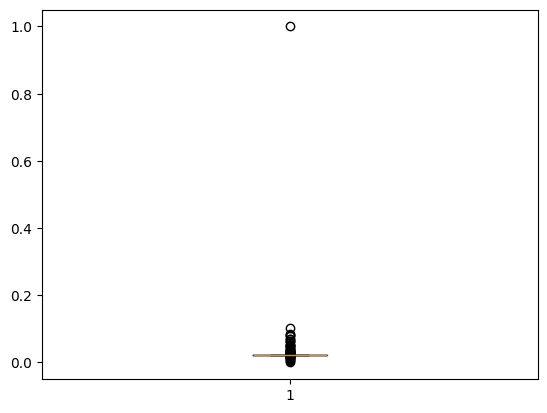

 Operating Profit Growth Rate


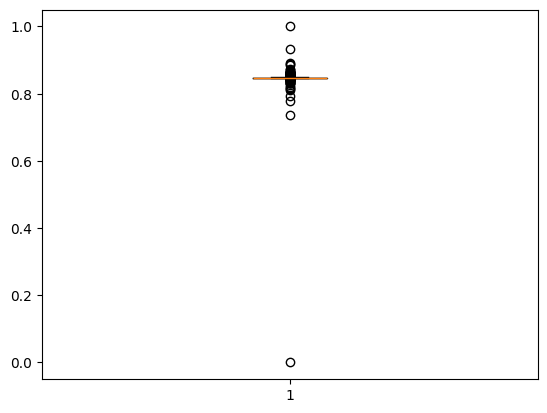

 After-tax Net Profit Growth Rate


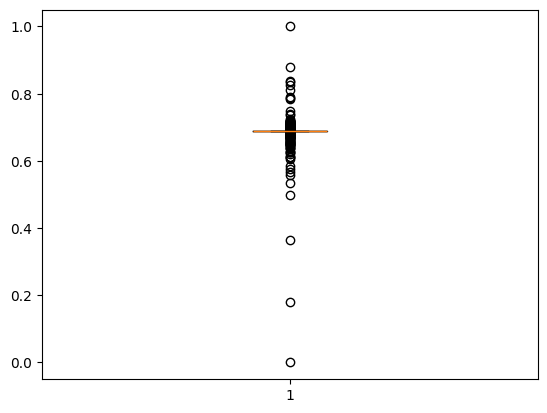

 Regular Net Profit Growth Rate


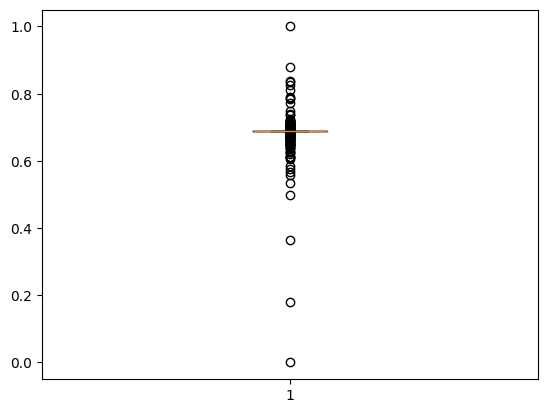

 Continuous Net Profit Growth Rate


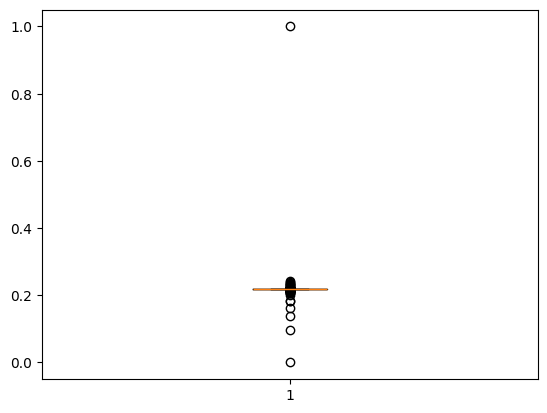

 Total Asset Growth Rate


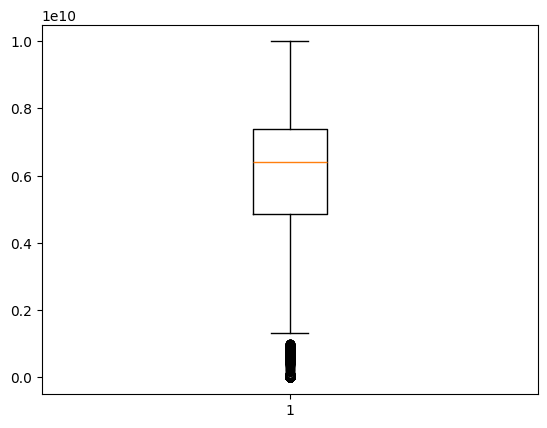

 Net Value Growth Rate


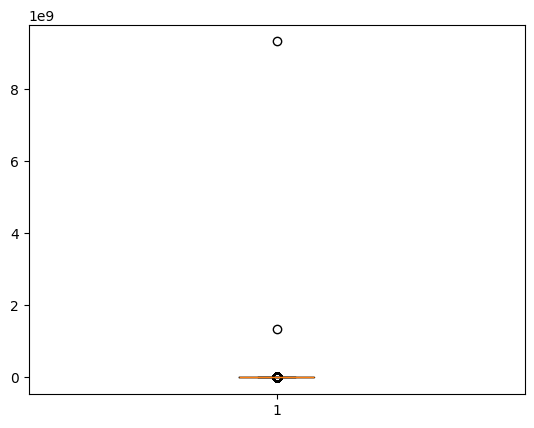

 Total Asset Return Growth Rate Ratio


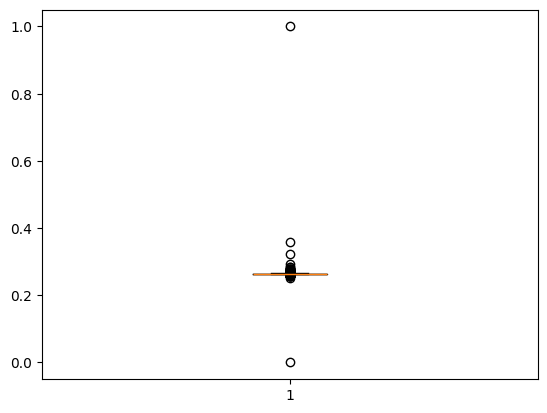

 Cash Reinvestment %


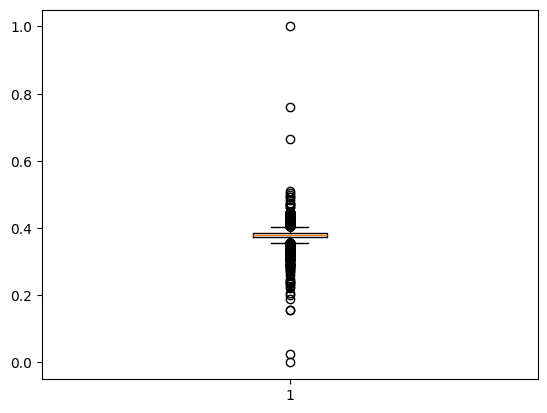

 Current Ratio


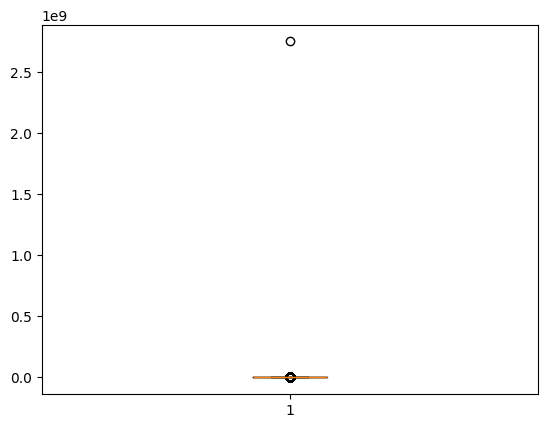

 Quick Ratio


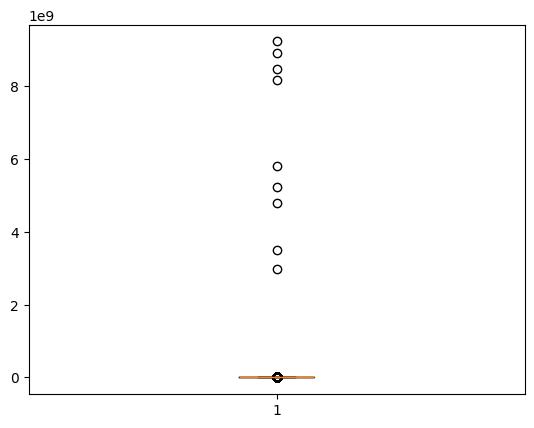

 Interest Expense Ratio


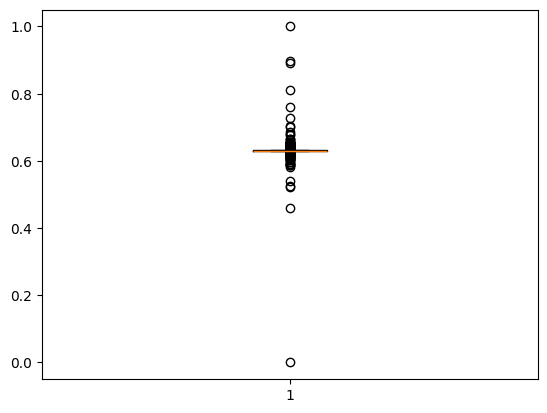

 Total debt/Total net worth


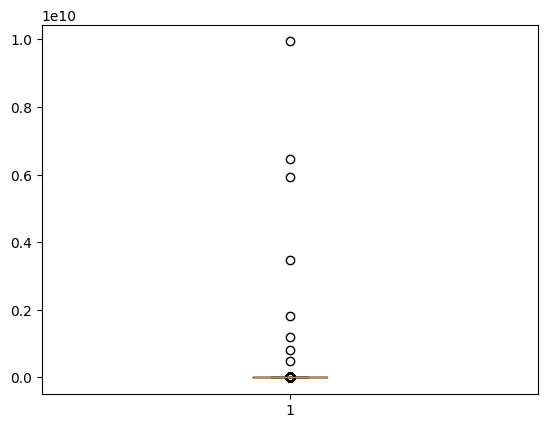

 Debt ratio %


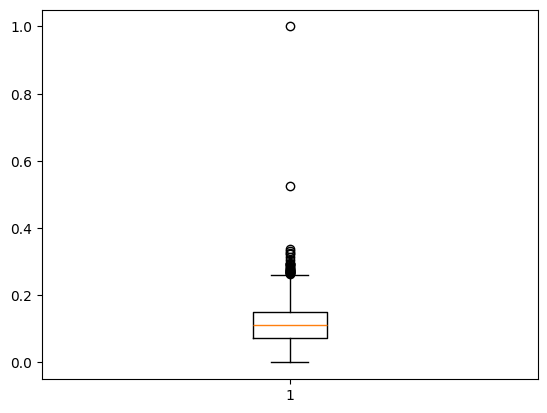

 Net worth/Assets


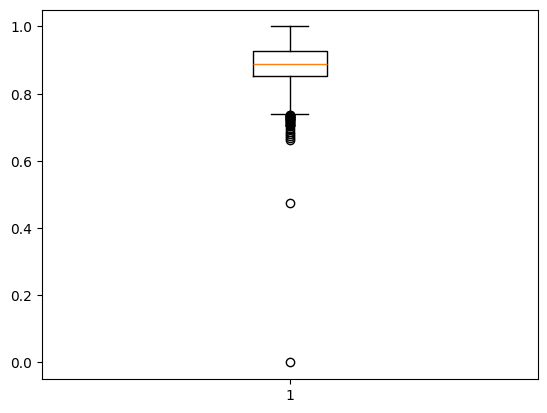

 Long-term fund suitability ratio (A)


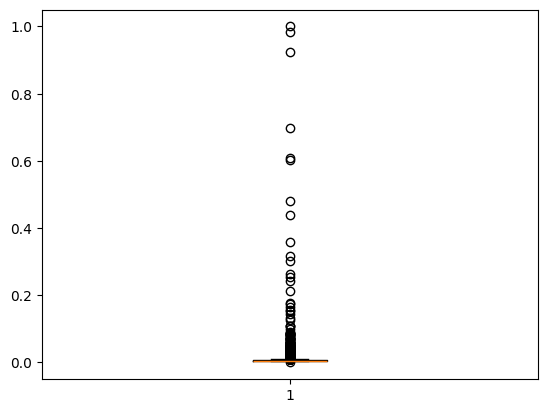

 Borrowing dependency


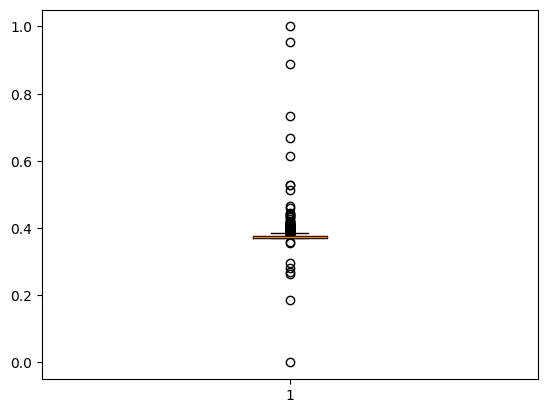

 Contingent liabilities/Net worth


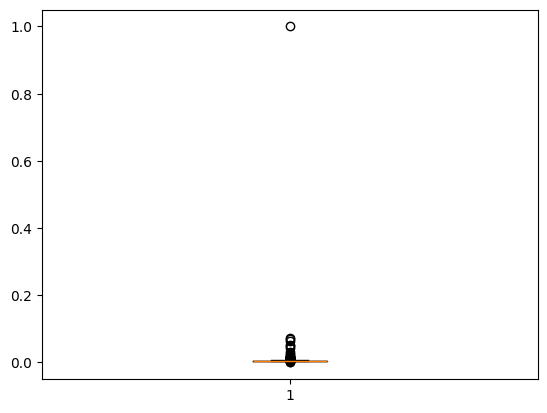

 Operating profit/Paid-in capital


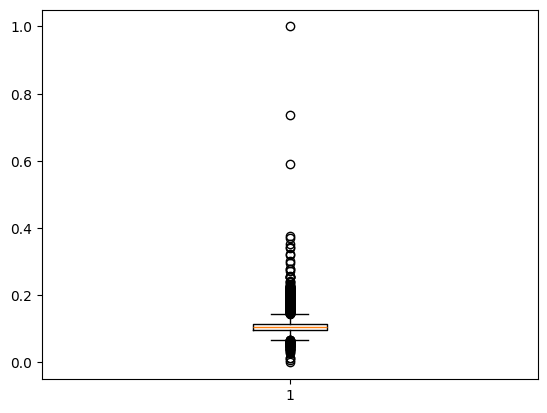

 Net profit before tax/Paid-in capital


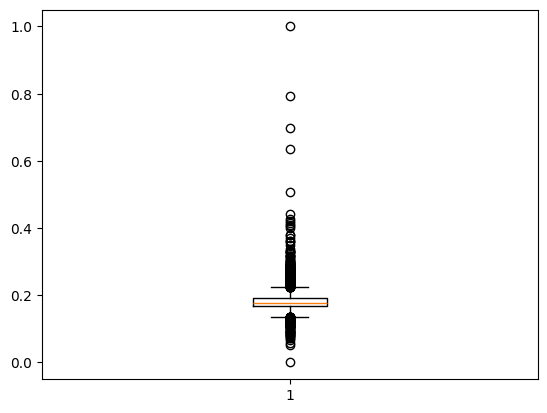

 Inventory and accounts receivable/Net value


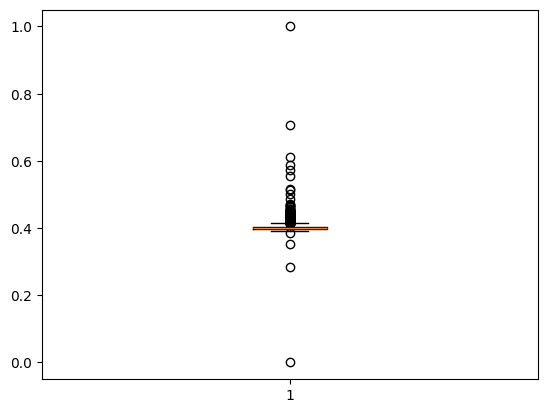

 Total Asset Turnover


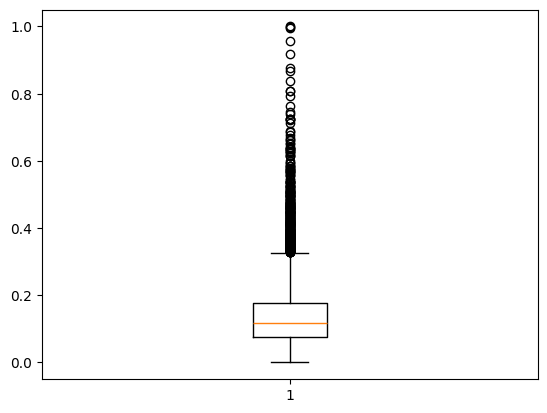

 Accounts Receivable Turnover


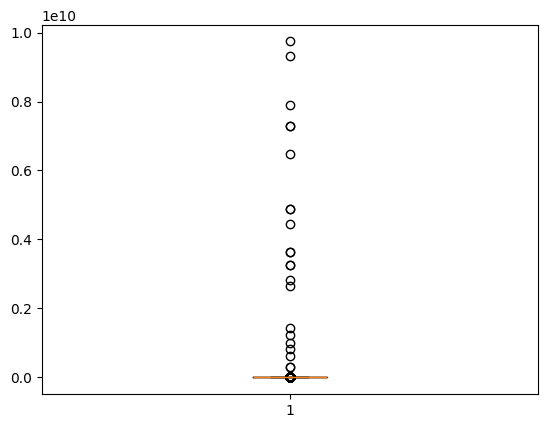

 Average Collection Days


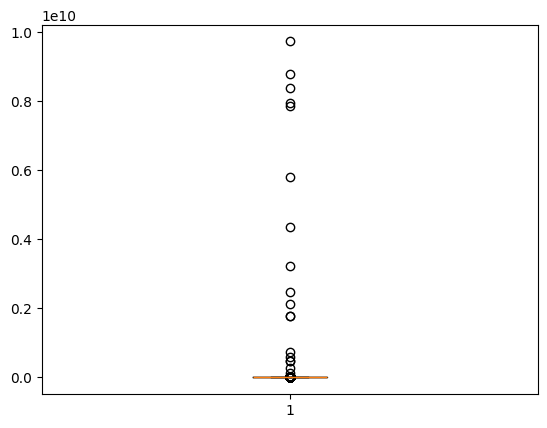

 Inventory Turnover Rate (times)


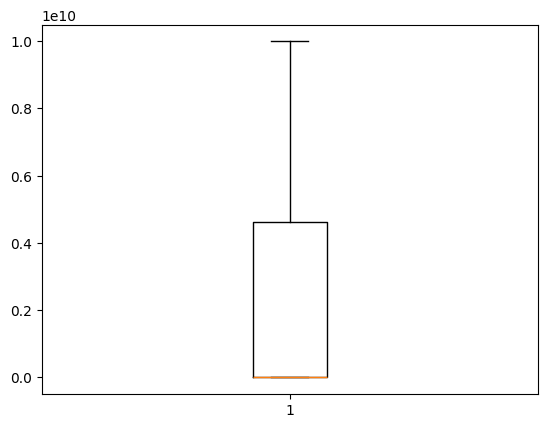

 Fixed Assets Turnover Frequency


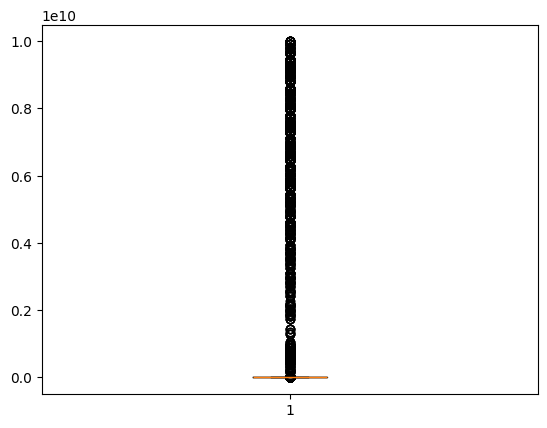

 Net Worth Turnover Rate (times)


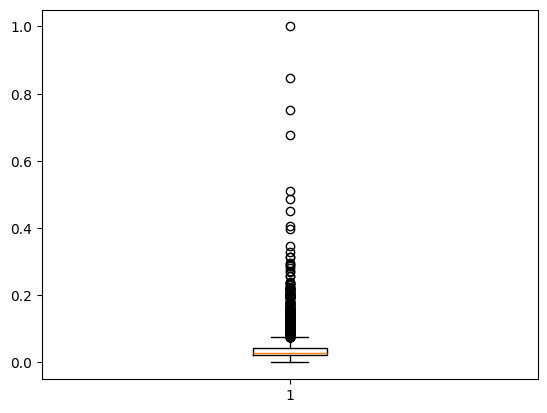

 Revenue per person


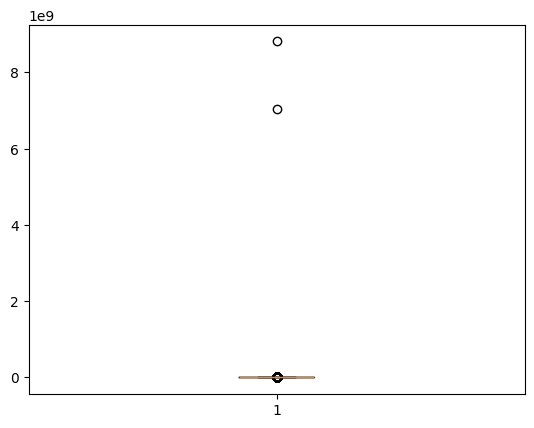

 Operating profit per person


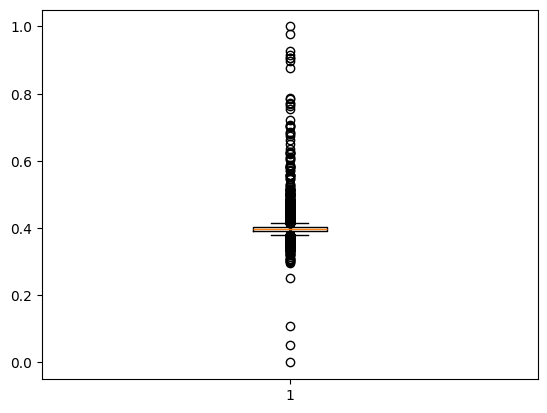

 Allocation rate per person


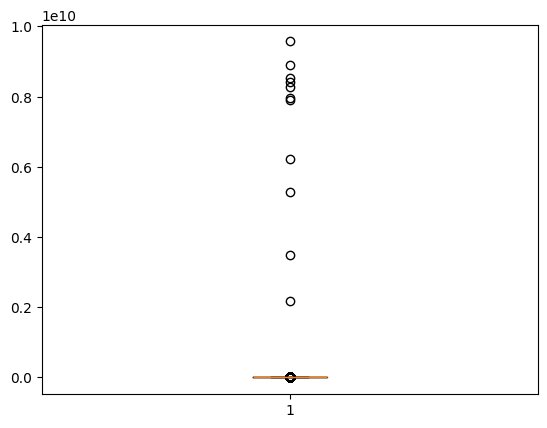

 Working Capital to Total Assets


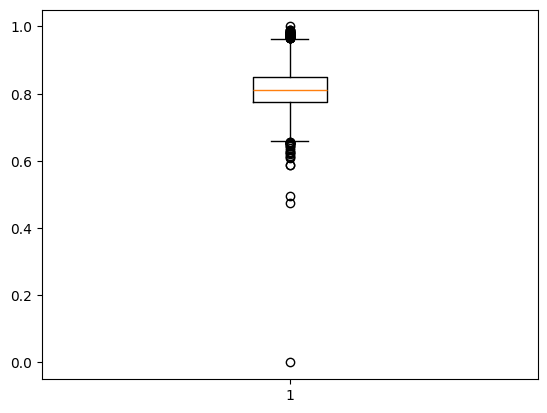

 Quick Assets/Total Assets


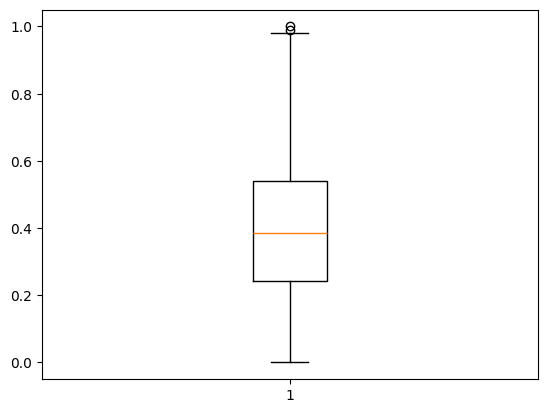

 Current Assets/Total Assets


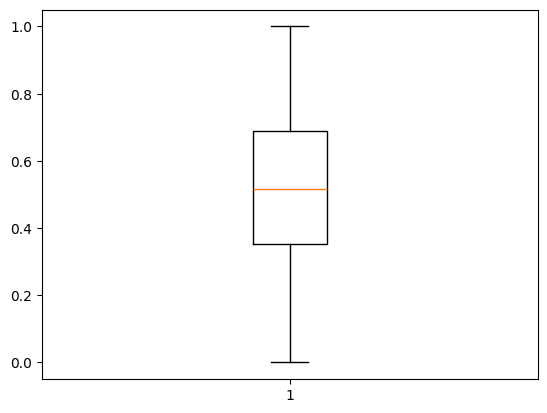

 Cash/Total Assets


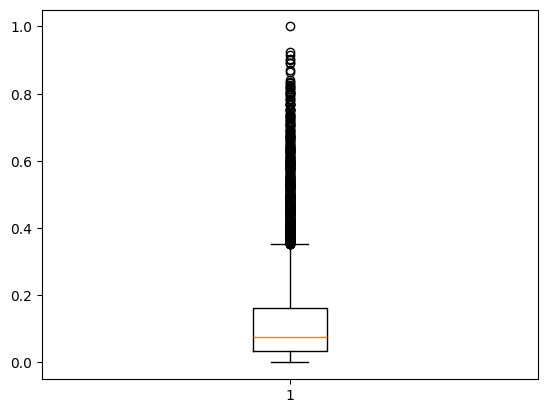

 Quick Assets/Current Liability


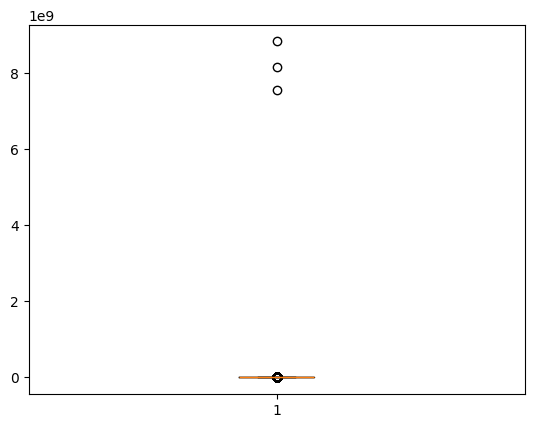

 Cash/Current Liability


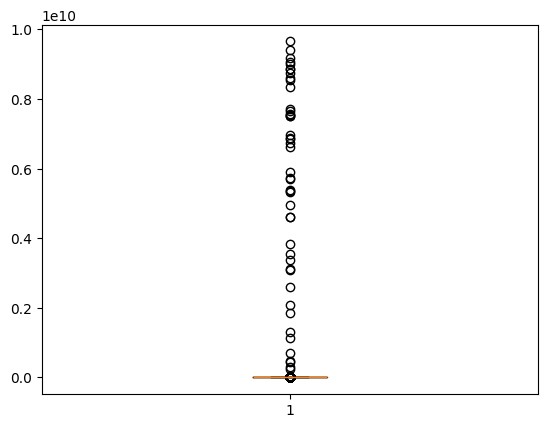

 Current Liability to Assets


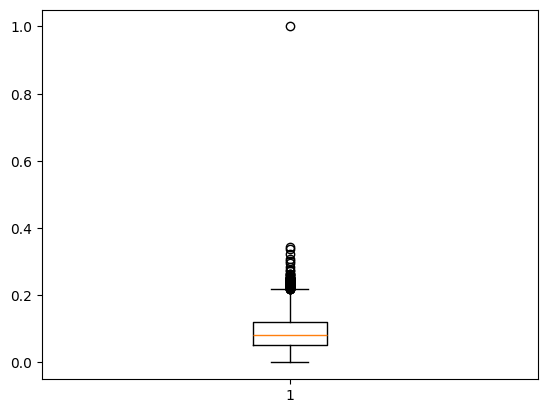

 Operating Funds to Liability


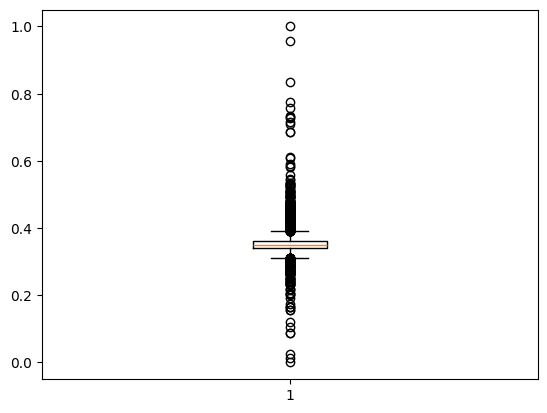

 Inventory/Working Capital


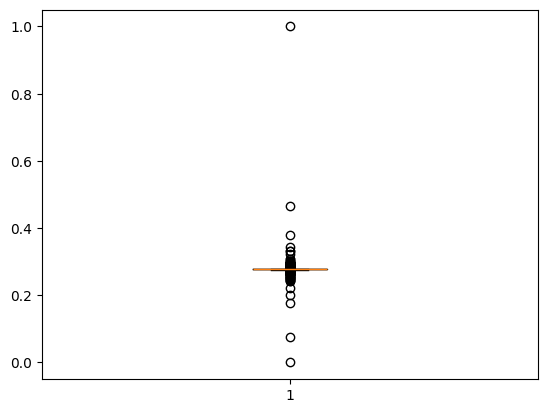

 Inventory/Current Liability


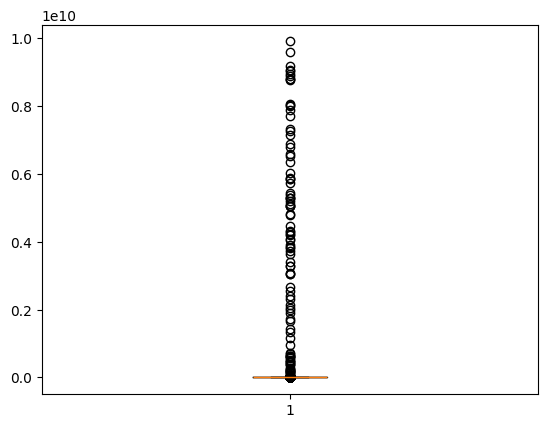

 Current Liabilities/Liability


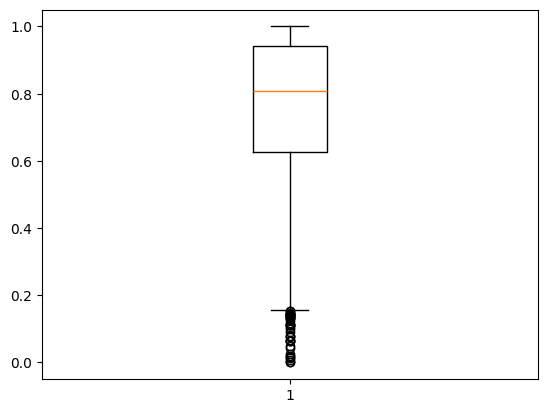

 Working Capital/Equity


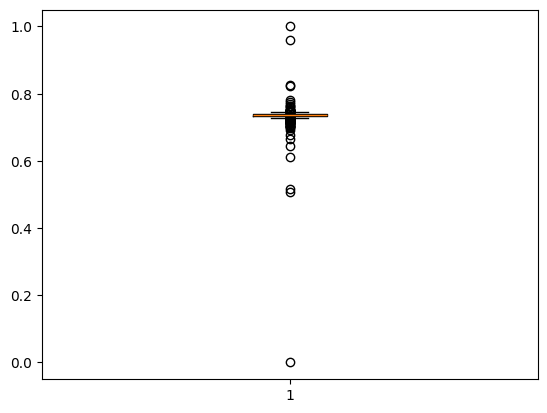

 Current Liabilities/Equity


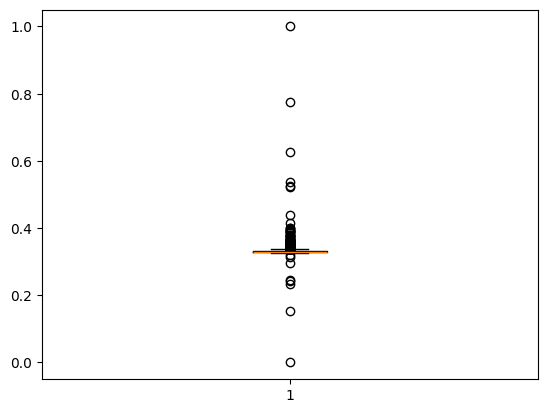

 Long-term Liability to Current Assets


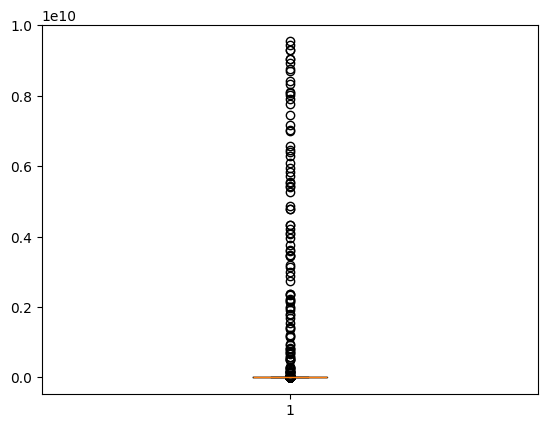

 Retained Earnings to Total Assets


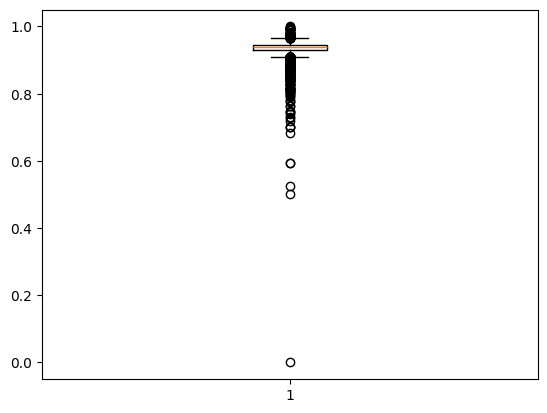

 Total income/Total expense


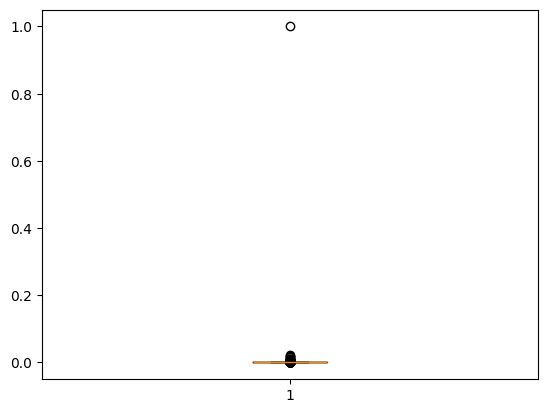

 Total expense/Assets


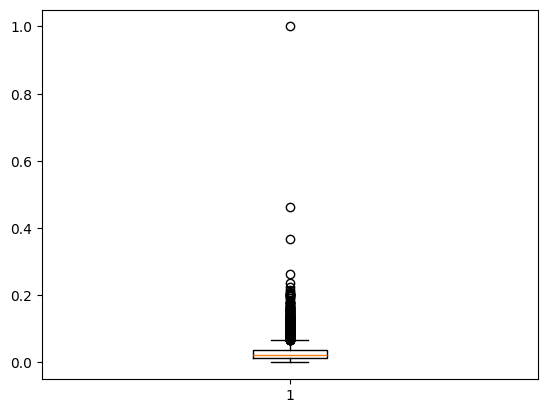

 Current Asset Turnover Rate


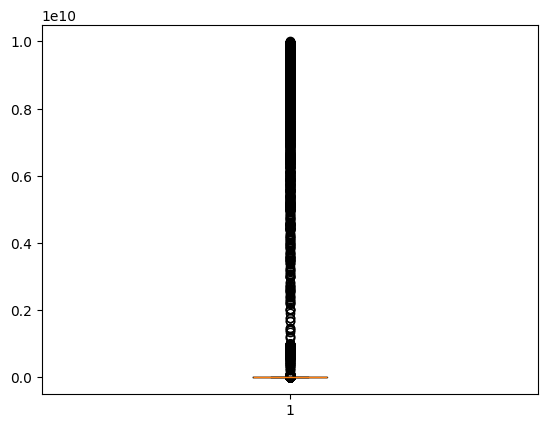

 Quick Asset Turnover Rate


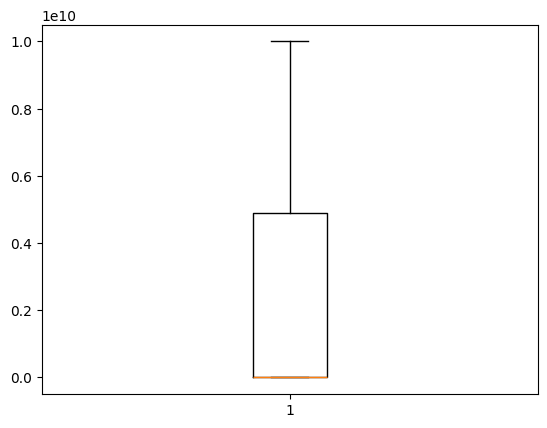

 Working capitcal Turnover Rate


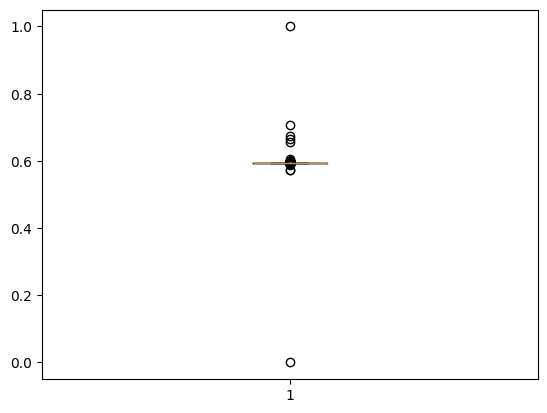

 Cash Turnover Rate


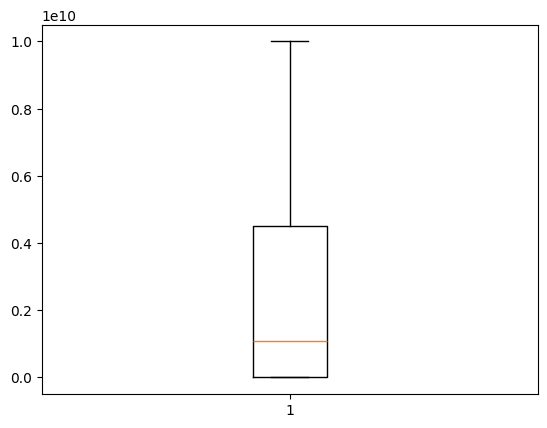

 Cash Flow to Sales


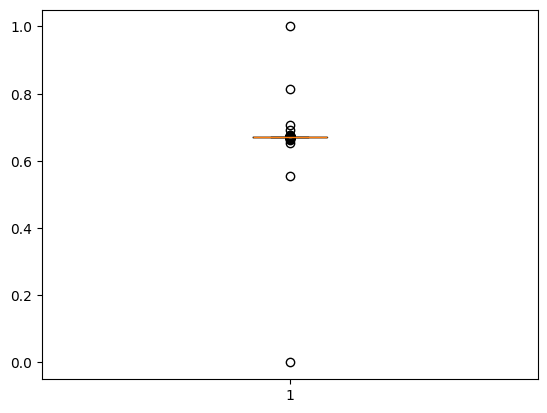

 Fixed Assets to Assets


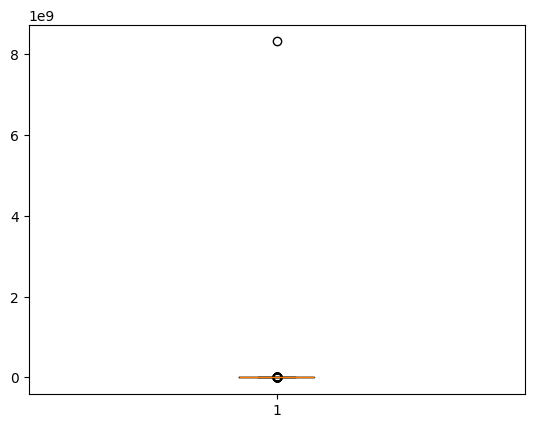

 Current Liability to Liability


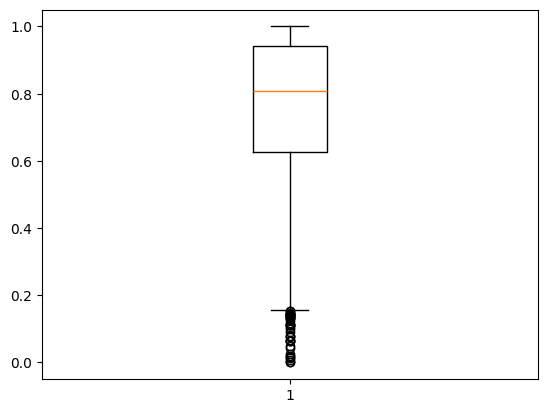

 Current Liability to Equity


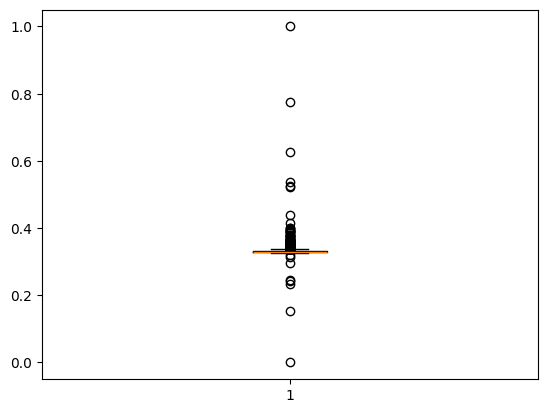

 Equity to Long-term Liability


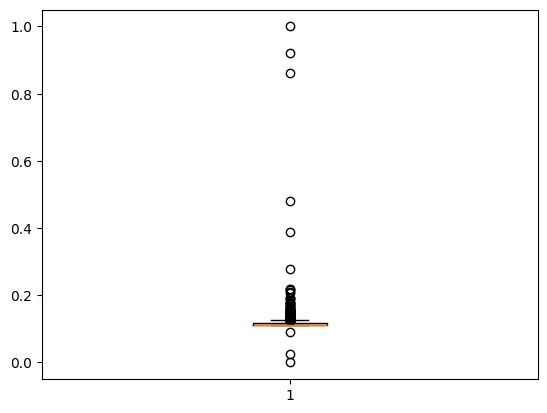

 Cash Flow to Total Assets


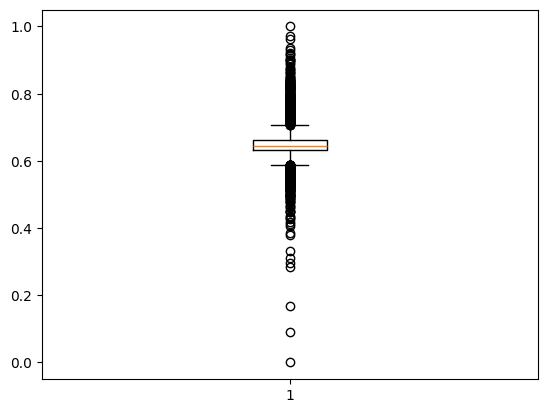

 Cash Flow to Liability


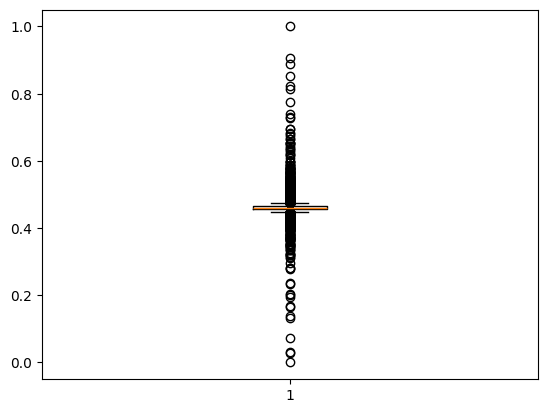

 CFO to Assets


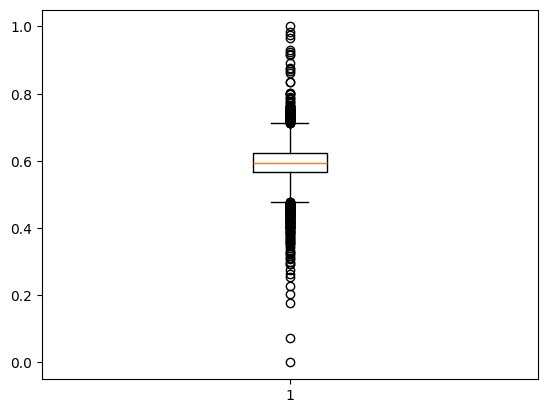

 Cash Flow to Equity


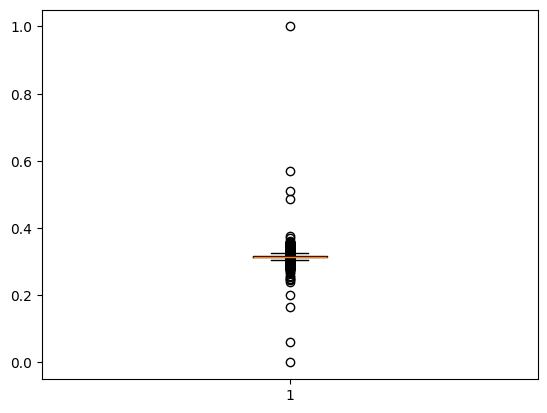

 Current Liability to Current Assets


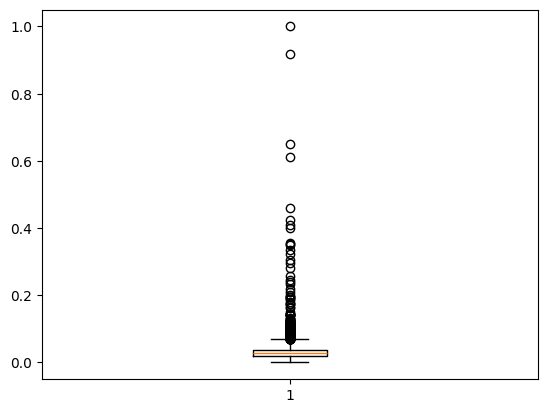

 Liability-Assets Flag


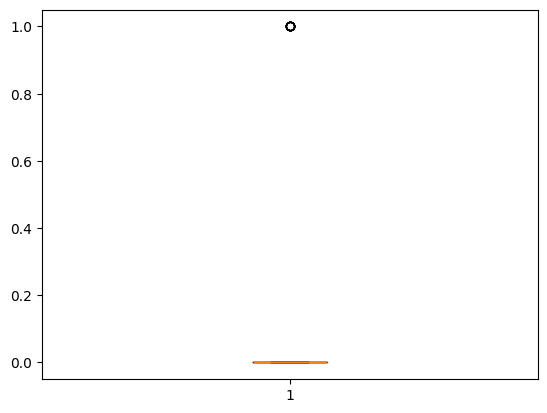

 Net Income to Total Assets


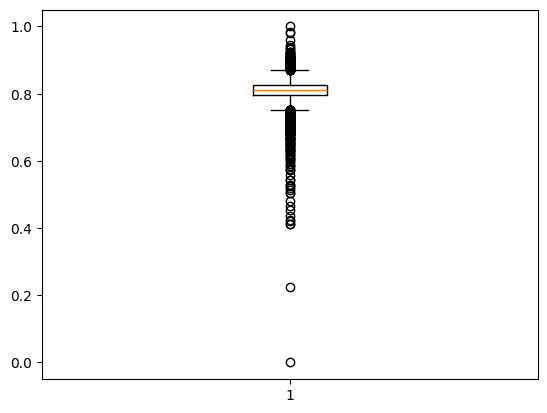

 Total assets to GNP price


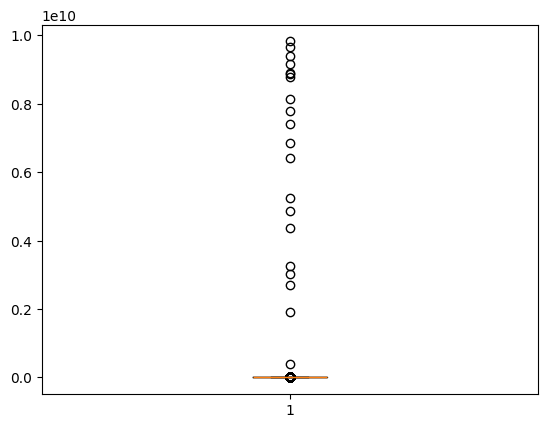

 No-credit Interval


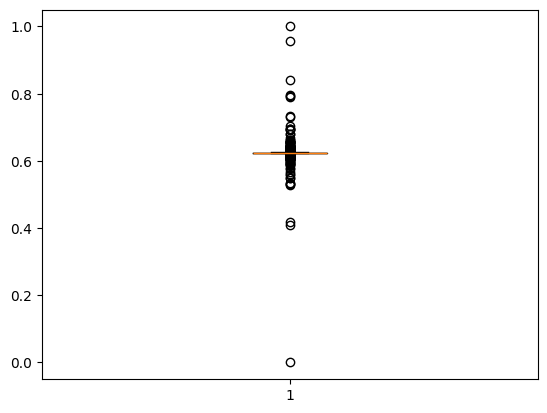

 Gross Profit to Sales


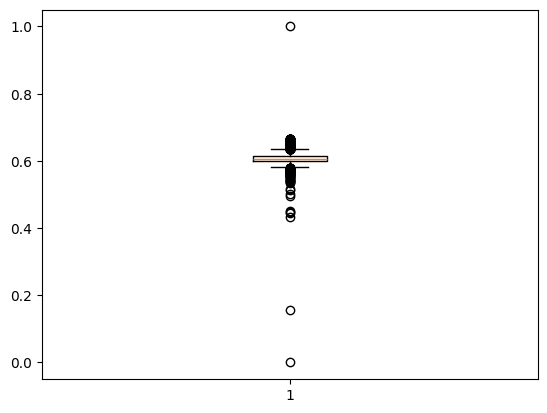

 Net Income to Stockholder's Equity


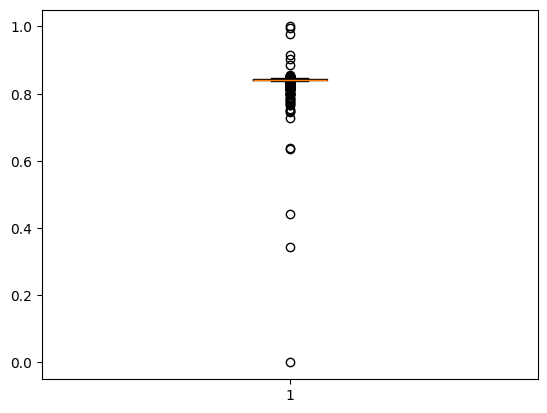

 Liability to Equity


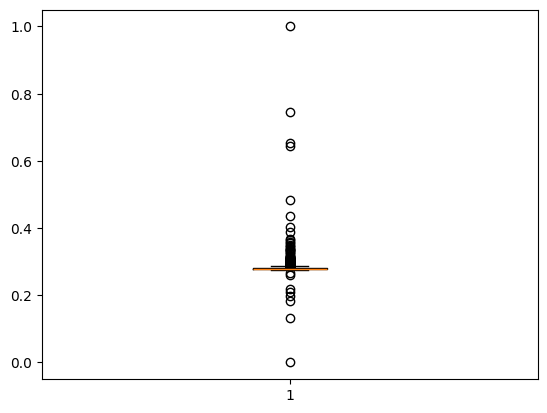

 Degree of Financial Leverage (DFL)


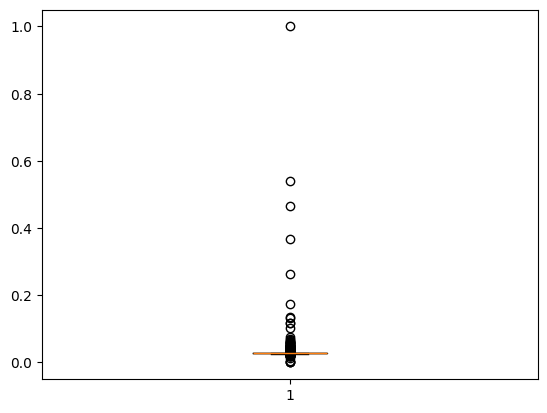

 Interest Coverage Ratio (Interest expense to EBIT)


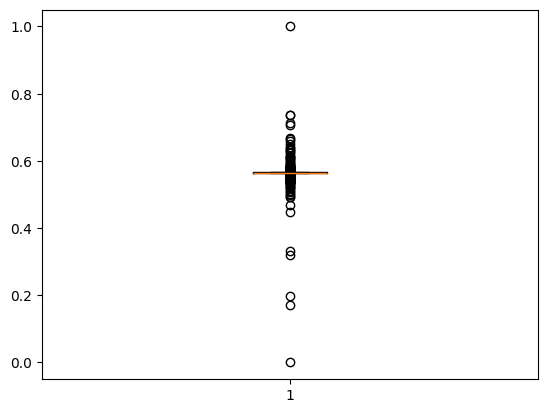

 Net Income Flag


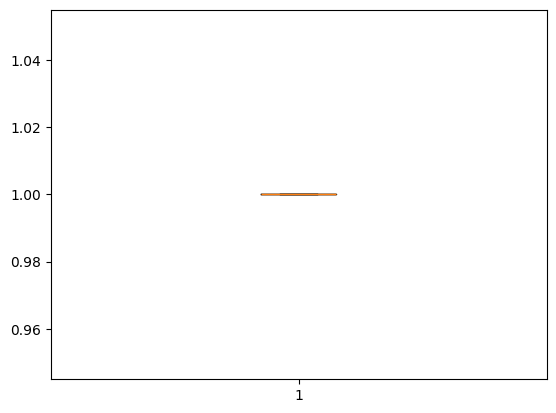

 Equity to Liability


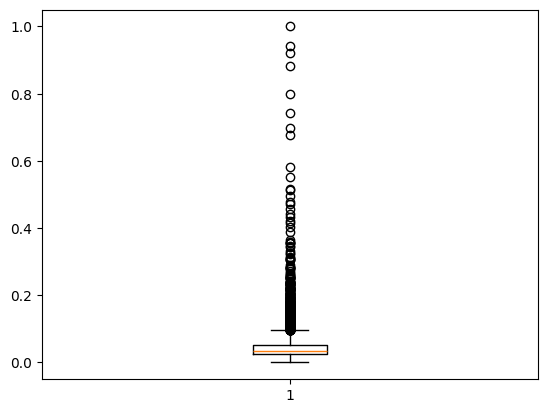

Id


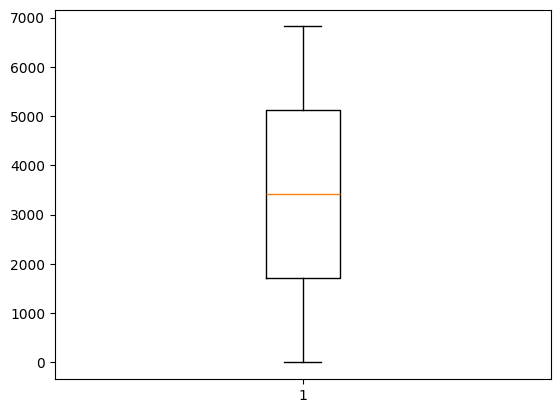

In [ ]:
for col in df.columns:
  print(col)
  plt.figure()
  plt.boxplot(df[col])
  plt.show()


# **Correlation**

In [ ]:
train_df.corr()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability,Id
Bankrupt?,1.000000,-0.262651,-0.280816,-0.273975,-0.101655,-0.100999,0.000160,-0.008031,-0.008471,-0.016566,...,0.037212,-0.004866,-0.101655,-0.172155,0.160026,0.010801,-0.004575,NaN,-0.080214,-0.100174
ROA(C) before interest and depreciation before interest,-0.262651,1.000000,0.938798,0.986780,0.331729,0.329842,0.036861,0.054247,0.050322,0.019392,...,-0.070587,0.010431,0.331729,0.268892,-0.143328,-0.017310,0.012663,NaN,0.044483,0.181890
ROA(A) before interest and % after tax,-0.280816,0.938798,1.000000,0.954677,0.327259,0.325361,0.032724,0.053961,0.050171,0.028903,...,-0.092736,0.013115,0.327261,0.282521,-0.137995,-0.011931,0.015315,NaN,0.048477,0.154413
ROA(B) before interest and depreciation after tax,-0.273975,0.986780,0.954677,1.000000,0.331274,0.329411,0.036234,0.054471,0.050947,0.021374,...,-0.087327,0.009744,0.331275,0.274615,-0.141851,-0.015428,0.013600,NaN,0.047686,0.175073
Operating Gross Margin,-0.101655,0.331729,0.327259,0.331274,1.000000,0.999606,0.004976,0.032646,0.027332,0.053629,...,0.022058,0.005826,1.000000,0.072158,-0.076435,-0.011450,-0.000227,NaN,0.087574,0.063037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Degree of Financial Leverage (DFL),0.010801,-0.017310,-0.011931,-0.015428,-0.011450,-0.010898,0.001033,0.000974,0.001039,-0.000557,...,-0.001992,-0.008867,-0.011450,-0.000045,0.001744,1.000000,0.017398,NaN,-0.016709,-0.046950
Interest Coverage Ratio (Interest expense to EBIT),-0.004575,0.012663,0.015315,0.013600,-0.000227,-0.000351,0.000357,0.000980,0.000947,0.001103,...,0.000458,0.000926,-0.000228,0.005286,0.000666,0.017398,1.000000,NaN,-0.007069,0.003261
Net Income Flag,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Equity to Liability,-0.080214,0.044483,0.048477,0.047686,0.087574,0.087664,-0.018244,-0.016320,-0.012294,0.011611,...,0.018842,0.049472,0.087572,0.027438,-0.151657,-0.016709,-0.007069,NaN,1.000000,0.057122


In [ ]:
corr_matrix = train_df.corr(numeric_only=True)

In [ ]:
corr_pairs = corr_matrix.unstack()

In [ ]:
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
corr_pairs = corr_pairs.drop_duplicates()

+ve correlation

In [ ]:
top_positive = corr_pairs.sort_values(ascending=False).head(50)
print(top_positive)

Current Liabilities/Liability                            Current Liability to Liability                       1.000000
Operating Gross Margin                                   Gross Profit to Sales                                1.000000
Net Value Per Share (A)                                  Net Value Per Share (C)                              0.999807
Operating Gross Margin                                   Realized Sales Gross Margin                          0.999606
Realized Sales Gross Margin                              Gross Profit to Sales                                0.999606
Net Value Per Share (B)                                  Net Value Per Share (A)                              0.999243
                                                         Net Value Per Share (C)                              0.999050
Operating Profit Per Share (Yuan ¥)                      Operating profit/Paid-in capital                     0.998319
After-tax Net Profit Growth Rate                

-ve correlation

In [ ]:
top_negative = corr_pairs.sort_values().head(50)
print(top_negative)

 Debt ratio %                                             Net worth/Assets                              -1.000000
 Net worth/Assets                                         Current Liability to Assets                   -0.834786
 Borrowing dependency                                     Net Income to Stockholder's Equity            -0.812012
 Net Income to Stockholder's Equity                       Liability to Equity                           -0.795023
 Contingent liabilities/Net worth                         Working Capital/Equity                        -0.773381
 Current Liabilities/Equity                               Net Income to Stockholder's Equity            -0.753482
 Working Capital/Equity                                   Current Liabilities/Equity                    -0.700736
                                                          Liability to Equity                           -0.657214
 Debt ratio %                                             Equity to Liability           

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [ ]:
def feature_engineering(data):

    df_fe = data.copy()

    df_fe.columns = df_fe.columns.str.strip()

    # -----------------------
    # numeric columns
    # -----------------------

    x_iforest = df_fe.select_dtypes(include='number')

    # remove target if exists
    if 'Bankrupt?' in x_iforest.columns:
        x_iforest = x_iforest.drop(columns=['Bankrupt?'])

    # -----------------------
    # Isolation Forest
    # -----------------------

    scaler = StandardScaler()

    x_scaled = scaler.fit_transform(x_iforest)

    iso_model = IsolationForest(
        contamination=0.02,
        random_state=42
    )

    iso_model.fit(x_scaled)

    # anomaly score
    df_fe['anomaly_score'] = iso_model.decision_function(x_scaled)

    # -----------------------
    # Feature Engineering
    # -----------------------

    df_fe['anomaly * Total debt/Total net worth'] = (
        df_fe['anomaly_score'] *
        df_fe['Total debt/Total net worth']
    )

    df_fe['Total debt/Total net worth / Working Capital to Total Assets'] = (
        df_fe['Total debt/Total net worth'] /
        (df_fe['Working Capital to Total Assets'] + 1e-6)
    )

    df_fe['Net Income to Total Assets * Total Asset Turnover'] = (
        df_fe['Net Income to Total Assets'] *
        df_fe['Total Asset Turnover']
    )

    df_fe['Cash/Total Assets / Debt ratio %'] = (
        df_fe['Cash/Total Assets'] /
        (df_fe['Debt ratio %'] + 1e-6)
    )

    df_fe['anomaly * Net Income to Total Assets'] = (
        df_fe['anomaly_score'] *
        df_fe['Net Income to Total Assets']
    )

    df_fe['risk_interaction'] = (
        df_fe['anomaly_score'] *
        df_fe['Total debt/Total net worth']
    )

    # -----------------------
    # Log Transform
    # -----------------------

    numeric_cols = df_fe.select_dtypes(include='number').columns

    for col in numeric_cols:

        if col == 'Bankrupt?':
            continue

        if (df_fe[col] > -1e-6).all() and df_fe[col].skew() > 2:
            df_fe[col] = np.log1p(df_fe[col])

    return df_fe

In [ ]:
df_fe=feature_engineering(train_df)
test_df=feature_engineering(test_df)

In [ ]:
df_fe.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income Flag,Equity to Liability,Id,anomaly_score,anomaly * Total debt/Total net worth,Total debt/Total net worth / Working Capital to Total Assets,Net Income to Total Assets * Total Asset Turnover,Cash/Total Assets / Debt ratio %,anomaly * Net Income to Total Assets,risk_interaction
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.264398,...,1,0.016335,0,0.049610,0.001055,0.031120,0.060469,0.019533,0.035563,0.001055
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.265096,...,1,0.020581,1,0.106483,0.001331,0.016508,0.050000,0.083719,0.084685,0.001331
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.263929,...,1,0.016340,2,0.092708,0.001970,0.025292,0.011547,0.004764,0.071818,0.001970
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.264938,...,1,0.023699,3,0.082306,0.000788,0.013103,0.064407,0.117298,0.060870,0.000788
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.265034,...,1,0.034875,4,0.117227,0.000604,0.006826,0.130551,0.124829,0.093197,0.000604


# **Feature Selection**

# **Boruta**

In [ ]:
!pip install boruta

In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df_fe.shape

(6000, 104)

In [ ]:
X=df_fe.drop(columns=['Bankrupt?'])
Y=df_fe['Bankrupt?']


rf=RandomForestClassifier(n_estimators=100,random_state=42)
bor=BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)
bor.fit(X.values,Y.values)
selected_features=X.columns[bor.support_]
selected_features

Index([' ROA(C) before interest and depreciation before interest',
       ' ROA(B) before interest and depreciation after tax',
       ' Non-industry income and expenditure/revenue',
       ' Continuous interest rate (after tax)',
       ' Interest-bearing debt interest rate', ' Net Value Per Share (B)',
       ' Net Value Per Share (A)', ' Net Value Per Share (C)',
       ' Persistent EPS in the Last Four Seasons',
       ' Per Share Net profit before tax (Yuan ¥)', ' Net Value Growth Rate',
       ' Quick Ratio', ' Interest Expense Ratio',
       ' Total debt/Total net worth', ' Debt ratio %', ' Net worth/Assets',
       ' Borrowing dependency', ' Net profit before tax/Paid-in capital',
       ' Working Capital to Total Assets', ' Cash/Total Assets',
       ' Cash/Current Liability', ' Inventory/Working Capital',
       ' Working Capital/Equity', ' Total income/Total expense',
       ' Net Income to Total Assets', ' Net Income to Stockholder's Equity',
       ' Liability to Equity', ' Degree of Financial Leverage (DFL)',
       ' Interest Coverage Ratio (Interest expense to EBIT)',
       ' Equity to Liability'],
      dtype='object')

# **ML Models**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,ConfusionMatrixDisplay,precision_recall_curve

financial_features=['ROA(B) before interest and depreciation after tax',
       'Non-industry income and expenditure/revenue',
       'Continuous interest rate (after tax)',
       'Interest-bearing debt interest rate', 'Net Value Per Share (B)',
       'Net Value Per Share (A)', 'Net Value Per Share (C)',
       'Persistent EPS in the Last Four Seasons',
       'Per Share Net profit before tax (Yuan ¥)', 'Net Value Growth Rate',
       'Quick Ratio', 'Interest Expense Ratio', 'Total debt/Total net worth',
       'Debt ratio %', 'Net worth/Assets', 'Borrowing dependency',
       'Net profit before tax/Paid-in capital',
       'Working Capital to Total Assets', 'Cash/Total Assets',
       'Working Capital/Equity', 'Net Income to Total Assets',
       "Net Income to Stockholder's Equity",
       'Degree of Financial Leverage (DFL)',
       'Interest Coverage Ratio (Interest expense to EBIT)',
       'Equity to Liability', 'Id',
       'Total debt/Total net worth / Working Capital to Total Assets',
       'Cash/Total Assets / Debt ratio %']

In [ ]:
X= df_fe[financial_features]
y= df_fe['Bankrupt?']

X_train,X_test,y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# **Logistic Regression**

In [ ]:
from sklearn.linear_model import LogisticRegression



log_model=LogisticRegression(class_weight='balanced',max_iter=2000,random_state=42)
log_model.fit(X_train, y_train)

y_pred=log_model.predict(X_test)
y_prob=log_model.predict_proba(X_test)[:,1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report")
print(classification_report(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))

Confusion Matrix
[[990 169]
 [  5  36]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.85      0.92      1159
           1       0.18      0.88      0.29        41

    accuracy                           0.85      1200
   macro avg       0.59      0.87      0.61      1200
weighted avg       0.97      0.85      0.90      1200


ROC-AUC Score: 0.8974725899114039


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


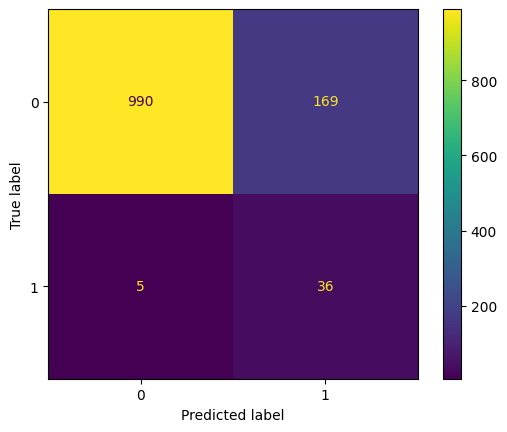

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot()

In [ ]:
print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob))


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

beta = 2

f2_scores = (1 + beta**2) * (precision[:-1] * recall[:-1]) / (
    (beta**2 * precision[:-1]) + recall[:-1] + 1e-8
)

best_idx = np.argmax(f2_scores)
best_threshold_log = thresholds[best_idx]

print("Best Threshold:", best_threshold_log)

y_predd = (y_prob >= best_threshold_log).astype(int)

Logistic ROC-AUC: 0.8974725899114039
Best Threshold: 0.664201611130455


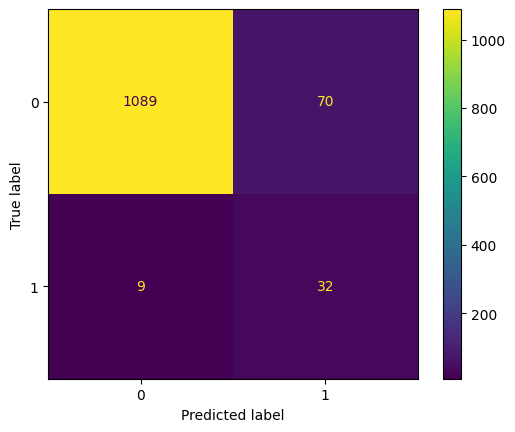

In [ ]:
cm = confusion_matrix(y_test, y_predd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot()

In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_predd))


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1159
           1       0.31      0.78      0.45        41

    accuracy                           0.93      1200
   macro avg       0.65      0.86      0.71      1200
weighted avg       0.97      0.93      0.95      1200



# **XGBoosting**

In [ ]:
!pip install optuna

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import optuna

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import optuna


def objective(trial):
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
  X.fillna(X.median(), inplace=True)


  n_estimators = trial.suggest_int("n_estimators",200, 800)

  max_depth = trial.suggest_int("max_depth",3,10)

  learning_rate = trial.suggest_float("learning_rate", 0.01,0.3,log=True)

  subsample = trial.suggest_float("subsample",0.5,1.0)

  colsample_bytree = trial.suggest_float("colsample_bytree",0.5,1.0)

  gamma = trial.suggest_float(
        "gamma",1e-8,10,log=True
    )

  min_child_weight = trial.suggest_int(
        "min_child_weight",1,10
    )
  reg_alpha = trial.suggest_float("reg_alpha", 1e-8, 10, log=True)

  reg_lambda = trial.suggest_float("reg_lambda", 1e-8, 10, log=True)



  skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

  aucs = []



  for train_idx, val_idx in skf.split(X, y):


        X_train = X.iloc[train_idx].copy()
        X_val = X.iloc[val_idx].copy()

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]



        model_xg = XGBClassifier(
            booster="gbtree",
            n_jobs=-1,
            random_state=42,

            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,

            subsample=subsample,
            colsample_bytree=colsample_bytree,
            scale_pos_weight=1,

            gamma=gamma,
            min_child_weight=min_child_weight,

            eval_metric="auc",
            enable_categorical=True
        )

        model_xg.fit(
            X_train,
            y_train
        )



        preds = model_xg.predict_proba(X_val)[:, 1]


        auc = roc_auc_score(
            y_val,
            preds
        )

        aucs.append(auc)


  return np.mean(aucs)

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

In [ ]:

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

Best AUC: 0.9436309686651654
Best Params: {'n_estimators': 791, 'max_depth': 3, 'learning_rate': 0.011780630018350061, 'subsample': 0.8657666354972001, 'colsample_bytree': 0.5669072392123802, 'gamma': 2.0643402801189602e-08, 'min_child_weight': 1, 'reg_alpha': 0.004581438713235177, 'reg_lambda': 1.3787086573699118e-08}


In [ ]:
model_xg = XGBClassifier(
    booster="gbtree",
    random_state=42,
    n_jobs=-1,
    n_estimators=791,
    max_depth=3,
    learning_rate=0.011780630018350061,

    subsample=0.8657666354972001,
    colsample_bytree=0.5669072392123802,

    gamma=2.0643402801189602e-08,
    min_child_weight=1,

    reg_alpha=0.004581438713235177,
    reg_lambda=1.3787086573699118e-08,
    enable_categorical=True,

    eval_metric="auc"
)

model_xg.fit(X_train, y_train)

y_pred_XG = model_xg.predict(X_test)
y_prob_XG = model_xg.predict_proba(X_test)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_XG))
print("\nClassification Report")
print(classification_report(y_test, y_pred_XG))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob_XG))


Confusion Matrix
[[1156    3]
 [  32    9]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1159
           1       0.75      0.22      0.34        41

    accuracy                           0.97      1200
   macro avg       0.86      0.61      0.66      1200
weighted avg       0.97      0.97      0.96      1200


ROC-AUC Score: 0.9544182327069172


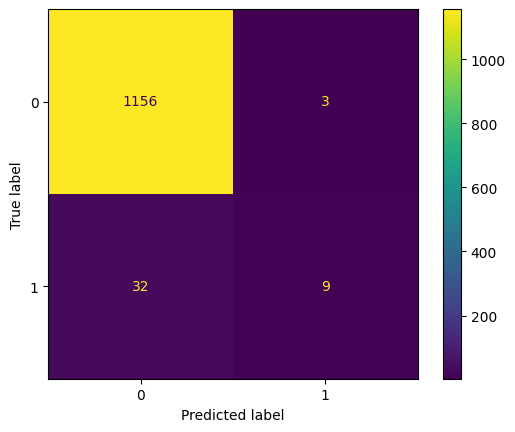

In [ ]:
cm = confusion_matrix(y_test, y_pred_XG)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot()

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_XG)

beta = 2

f2_scores = (1 + beta**2) * (precision[:-1] * recall[:-1]) / (
    (beta**2 * precision[:-1]) + recall[:-1] + 1e-8
)

best_idx = np.argmax(f2_scores)
best_threshold_xg = thresholds[best_idx]

print("Best Threshold:", best_threshold_xg)

y_pred_XG = (y_prob_XG >= best_threshold_xg).astype(int)

Best Threshold: 0.20074525


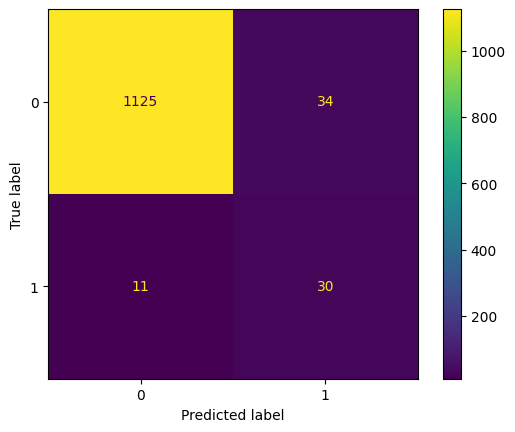

In [ ]:
cm = confusion_matrix(y_test, y_pred_XG)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot()

In [ ]:
print("\nClassification Report")
print(classification_report(y_test, y_pred_XG))


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1159
           1       0.47      0.73      0.57        41

    accuracy                           0.96      1200
   macro avg       0.73      0.85      0.78      1200
weighted avg       0.97      0.96      0.97      1200



# **AdaBoost**

# **Random Sampling**

In [ ]:
import optuna

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier

from imblearn.over_sampling import KMeansSMOTE
from imblearn.pipeline import Pipeline

In [ ]:
def objective(trial):


    # SMOTE Parameters

    k_neighbors = trial.suggest_int("k_neighbors", 2, 10)

    cluster_balance_threshold = trial.suggest_float(
        "cluster_balance_threshold",
        0.001,
        0.05
    )


    # Base RandomForest


    max_depth = trial.suggest_int("max_depth", 1, 5)


    base_model = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=trial.suggest_int("rf_estimators", 5, 30),
        random_state=42,
        n_jobs=-1
    )


    # AdaBoost Parameters


    ada_model = AdaBoostClassifier(
        estimator=base_model,
        n_estimators=trial.suggest_int("ada_estimators", 50, 500),
        learning_rate=trial.suggest_float(
            "learning_rate",
            0.001,
            1.0,
            log=True
        ),
        random_state=42
    )



    pipeline = Pipeline([
        (
            "smote",
            KMeansSMOTE(
                kmeans_estimator=3,
                k_neighbors=k_neighbors,
                cluster_balance_threshold=cluster_balance_threshold,
                random_state=42
            )
        ),
        ("model", ada_model)
    ])


    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1
    )

    return scores.mean()


study2= optuna.create_study(direction="maximize")

study2.optimize(
    objective,
    n_trials=20,
    show_progress_bar=True
)



print("Best ROC-AUC:", study2.best_value)

print("\nBest Parameters:")
print(study2.best_params)

Best ROC-AUC: 0.9329528231430617

Best Parameters:
{'k_neighbors': 3, 'cluster_balance_threshold': 0.02413661629721559, 'max_depth': 5, 'rf_estimators': 21, 'ada_estimators': 315, 'learning_rate': 0.0679637334354288}

In [ ]:
# best_params = study2.best_params


best_smote = KMeansSMOTE(
    kmeans_estimator=3,
    k_neighbors=3,
    cluster_balance_threshold=0.02413661629721559,
    random_state=42
)


best_base = RandomForestClassifier(
    max_depth=5,
    n_estimators=21,
    random_state=42,
    n_jobs=-1
)


best_ada = AdaBoostClassifier(
    estimator=best_base,
    n_estimators=315,
    learning_rate=0.0679637334354288,
    random_state=42
)


X_train_res, y_train_res = best_smote.fit_resample(
    X_train,
    y_train
)


best_ada.fit(X_train_res, y_train_res)

AdaBoostClassifier(estimator=RandomForestClassifier(max_depth=5,
                                                    n_estimators=21, n_jobs=-1,
                                                    random_state=42),
                   learning_rate=0.0679637334354288, n_estimators=315,
                   random_state=42)

In [ ]:
y_pred = best_ada.predict(X_test)

y_proba = best_ada.predict_proba(X_test)[:, 1]

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_proba))

Confusion Matrix
[[1139   20]
 [  22   19]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1159
           1       0.49      0.46      0.47        41

    accuracy                           0.96      1200
   macro avg       0.73      0.72      0.73      1200
weighted avg       0.96      0.96      0.96      1200


ROC-AUC Score:
0.9431069677392201


Best Threshold: 0.15036086411224248


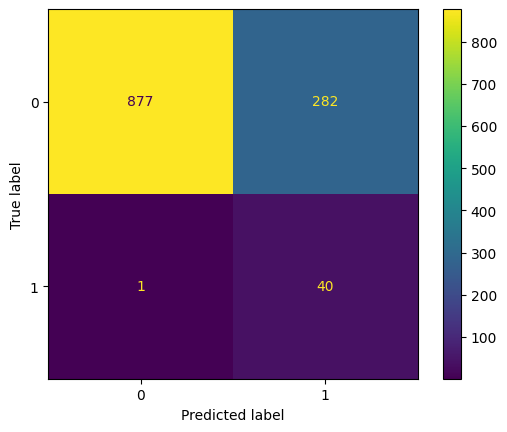

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

beta = 7

f2_scores = (1 + beta**2) * (precision[:-1] * recall[:-1]) / (
    (beta**2 * precision[:-1]) + recall[:-1] + 1e-8
)

best_idx = np.argmax(f2_scores)
best_threshold_lg = thresholds[best_idx]

print("Best Threshold:", best_threshold_lg)

y_pred_ada2 = (y_proba >= best_threshold_lg).astype(int)

cm = confusion_matrix(y_test, y_pred_ada2)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['0','1'])
disp.plot()

In [ ]:
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

X_test_final=test_df[financial_features]

results = []

models = {
    "Logistic": (log_model, best_threshold_log),
    "XGBoost": (model_xg, best_threshold_xg),
    "AdaBoost": (best_ada, best_threshold_lg)
}

for name, (model, threshold) in models.items():

    prob = model.predict_proba(X_test_final)[:,1]

    pred = (prob >= threshold).astype(int)


    results.append({
        "Model": name,
        "Recall": recall_score(y_test_true, pred),
        "F1": f1_score(y_test_true, pred),
        "ROC-AUC": roc_auc_score(y_test_true, prob)
    })
    print("Model: ",name)
    print(confusion_matrix(y_test_true, pred))


results_df = pd.DataFrame(results)

print(results_df.sort_values(
    "Recall",
    ascending=False
))

Model:  Logistic
[[790  14]
 [  3  12]]
Model:  XGBoost
[[782  22]
 [  4  11]]
Model:  AdaBoost
[[712  92]
 [  1  14]]
      Model    Recall        F1   ROC-AUC
2  AdaBoost  0.933333  0.231405  0.984163
0  Logistic  0.800000  0.585366  0.982255
1   XGBoost  0.733333  0.458333  0.979353


In [ ]:
X_test_final = test_df[financial_features]

results = []

models = {
    "Logistic": log_model,
    "XGBoost": model_xg,
    "AdaBoost": best_ada
}

for name, model in models.items():


    pred = model.predict(X_test_final)

    prob = model.predict_proba(X_test_final)[:, 1]

    results.append({
        "Model": name,
        "Recall": recall_score(y_test_true, pred),
        "F1": f1_score(y_test_true, pred),
        "ROC-AUC": roc_auc_score(y_test_true, prob)
    })

    print("Model:", name)
    print(confusion_matrix(y_test_true, pred))


results_df = pd.DataFrame(results)

print(results_df.sort_values("Recall", ascending=False))

Model: Logistic
[[777  27]
 [  2  13]]
Model: XGBoost
[[800   4]
 [  7   8]]
Model: AdaBoost
[[797   7]
 [  6   9]]
      Model    Recall        F1   ROC-AUC
0  Logistic  0.866667  0.472727  0.982255
2  AdaBoost  0.600000  0.580645  0.984163
1   XGBoost  0.533333  0.592593  0.979353


**We care about lower FN value**

# **Final Decision: Logistic Regression + Tuned Threshold**

In [ ]:
import joblib

model_package = {
    "model": log_model,
    "threshold": best_threshold_log,
    "features": financial_features
}

joblib.dump(model_package, "bankruptcy_logistic_model.pkl")